# poly2mask.ipynb

In [2]:
import numpy as np
import shapely.wkt
from shapely.affinity import translate, scale
from rasterio import features
from typing import Tuple
import matplotlib.pyplot as plt

In [3]:
def generate_polygon_mask(wkt_polygon: str, image_size: int) -> np.ndarray:
    """
    Converts a WKT polygon into a binary numpy mask, scaled to fit the image bounds.

    Args:
        wkt_polygon: The polygon geometry represented as a WKT string.
        image_size: The width and height of the resulting square output image.

    Returns:
        A 2D numpy array (uint8) where 1 represents the polygon and 0 the background.
    """
    # Parse the WKT
    poly = shapely.wkt.loads(wkt_polygon)
    
    # Get bounds: (minx, miny, maxx, maxy)
    minx, miny, maxx, maxy = poly.bounds
    width = maxx - minx
    height = maxy - miny
    
    # Calculate scaling factor to fit the polygon into the image size
    # We use a small buffer (0.95) to ensure it doesn't touch the absolute edges
    scale_factor = (image_size * 0.95) / max(width, height)
    
    # 1. Center the polygon at the origin (0,0)
    poly = translate(poly, xoff=-minx - width/2, yoff=-miny - height/2)
    
    # 2. Scale the polygon
    poly = scale(poly, xfact=scale_factor, yfact=scale_factor, origin=(0, 0))
    
    # 3. Move the polygon to the center of the image coordinate system
    poly = translate(poly, xoff=image_size/2, yoff=image_size/2)
    
    # Rasterize the polygon into a numpy array
    mask = features.rasterize(
        [poly],
        out_shape=(image_size, image_size),
        fill=0,
        default_value=1,
        dtype=np.uint8
    )
    
    return mask

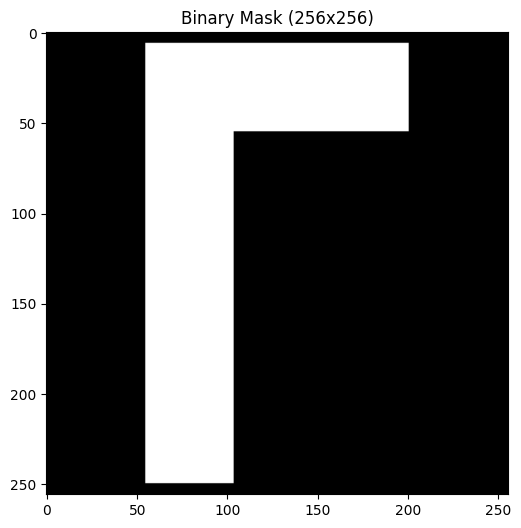

In [7]:
def visualize_mask(wkt: str, size: int):
    mask = generate_polygon_mask(wkt, size)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap='gray', origin='upper')
    plt.title(f"Binary Mask ({size}x{size})")

# Example: An L-shaped polygon
l_shape_wkt = "POLYGON ((0 0, 3 0, 3 1, 1 1, 1 5, 0 5, 0 0))"
visualize_mask(l_shape_wkt, 256)